# Credit score prediction (train / test datasets)

This notebook loads **`train.csv`** (with `Credit_Score`) and **`test.csv`** (no labels), cleans messy values, compares sklearn models, saves the best **pipeline as Joblib** (pickle-compatible), optionally trains a small **Keras** classifier and saves **`.h5`**, and writes predictions for the test set.

**Target:** `Credit_Score` ∈ {`Good`, `Standard`, `Poor`} (multiclass classification).

Artifacts are written to `./artifacts/` for use from the Node backend (e.g. spawn a Python script that loads the joblib pipeline).

In [1]:
from pathlib import Path
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import classification_report, f1_score, accuracy_score, confusion_matrix
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OrdinalEncoder

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

BASE = Path(".")
ART = BASE / "artifacts"
ART.mkdir(exist_ok=True)

TRAIN_PATH = BASE / "train.csv"
TEST_PATH = BASE / "test.csv"
print("Train:", TRAIN_PATH.resolve())
print("Test:", TEST_PATH.resolve())

Train: /Volumes/Biswarup_Harddisk/Ayush Project/inclusionnet/dataset_ml/train.csv
Test: /Volumes/Biswarup_Harddisk/Ayush Project/inclusionnet/dataset_ml/test.csv


In [2]:
train_df = pd.read_csv(TRAIN_PATH, low_memory=False)
test_df = pd.read_csv(TEST_PATH, low_memory=False)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("\nTrain columns:", list(train_df.columns))
print("\nTarget distribution:")
display(train_df["Credit_Score"].value_counts())

Train shape: (100000, 28)
Test shape: (50000, 27)

Train columns: ['ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN', 'Occupation', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Credit_History_Age', 'Payment_of_Min_Amount', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance', 'Credit_Score']

Target distribution:


Credit_Score
Standard    53174
Poor        28998
Good        17828
Name: count, dtype: int64

## Exploratory analysis
Quick view of missing values and class balance.

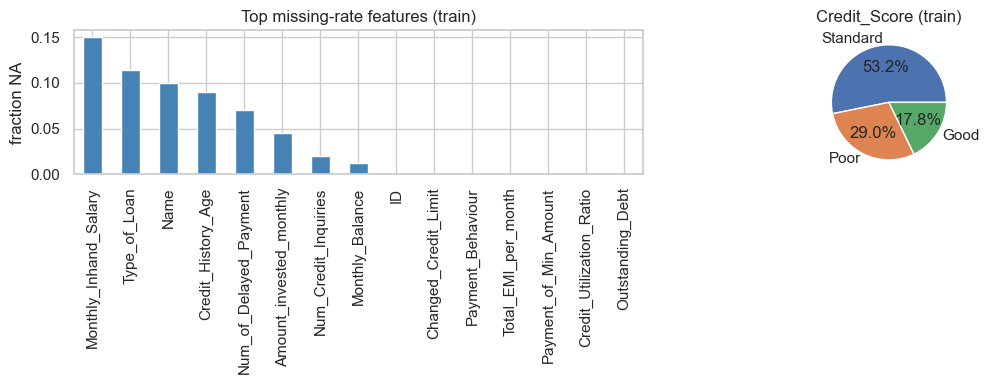

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
miss = train_df.isna().mean().sort_values(ascending=False).head(15)
miss.plot.bar(ax=ax[0], color="steelblue")
ax[0].set_title("Top missing-rate features (train)")
ax[0].set_ylabel("fraction NA")

train_df["Credit_Score"].value_counts().plot.pie(ax=ax[1], autopct="%1.1f%%")
ax[1].set_ylabel("")
ax[1].set_title("Credit_Score (train)")
plt.tight_layout()
plt.show()

## Preprocessing
- Drop identifiers / PII: `ID`, `Customer_ID`, `Name`, `SSN`.
- Coerce numeric columns after stripping junk (`_`, `NA`, placeholders).
- Parse `Credit_History_Age` into total months.
- Ordinal-encode categoricals with unknown handling.

In [4]:
import sys
from pathlib import Path

_here = Path.cwd().resolve()
for _p in (_here, _here / "dataset_ml", _here.parent / "dataset_ml"):
    if (_p / "credit_preprocess.py").is_file():
        if str(_p) not in sys.path:
            sys.path.insert(0, str(_p))
        break

from credit_preprocess import CAT_COLS, TARGET, numeric_feature_names, prepare_features

train_raw = train_df.copy()
y = train_raw[TARGET].astype(str).str.strip()
le_target = LabelEncoder()
y_enc = le_target.fit_transform(y)

X_train_full = prepare_features(train_raw)
num_features = [c for c in numeric_feature_names() if c in X_train_full.columns]
cat_features = [c for c in CAT_COLS if c in X_train_full.columns]
print("Numeric:", num_features)
print("Categorical:", cat_features)

Numeric: ['Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries', 'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Total_EMI_per_month', 'Amount_invested_monthly', 'Monthly_Balance', 'Credit_History_Age_months']
Categorical: ['Month', 'Occupation', 'Type_of_Loan', 'Credit_Mix', 'Payment_of_Min_Amount', 'Payment_Behaviour']


In [5]:
numeric_pipe = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ]
)

categorical_pipe = Pipeline(
    steps=[
        (
            "enc",
            OrdinalEncoder(
                handle_unknown="use_encoded_value",
                unknown_value=-1,
            ),
        ),
    ]
)

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_pipe, num_features),
        ("cat", categorical_pipe, cat_features),
    ],
    remainder="drop",
)

models = {
    "hgb": HistGradientBoostingClassifier(
        max_iter=400,
        learning_rate=0.06,
        max_depth=12,
        min_samples_leaf=20,
        l2_regularization=1.0,
        class_weight="balanced",
        random_state=42,
    ),
    "rf": RandomForestClassifier(
        n_estimators=200,
        max_depth=24,
        min_samples_leaf=4,
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=42,
    ),
}

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_full,
    y_enc,
    test_size=0.2,
    random_state=42,
    stratify=y_enc,
)

results = []
pipelines = {}
for name, clf in models.items():
    pipe = Pipeline([("prep", clone(preprocess)), ("clf", clone(clf))])
    pipe.fit(X_tr, y_tr)
    pred = pipe.predict(X_val)
    acc = accuracy_score(y_val, pred)
    f1 = f1_score(y_val, pred, average="macro")
    results.append({"model": name, "accuracy": acc, "macro_f1": f1})
    pipelines[name] = pipe
    print(f"=== {name} ===")
    print(classification_report(y_val, pred, target_names=le_target.classes_))

res_df = pd.DataFrame(results).sort_values("macro_f1", ascending=False)
display(res_df)
best_name = res_df.iloc[0]["model"]
print("Best model (by macro F1):", best_name)

=== hgb ===
              precision    recall  f1-score   support

        Good       0.51      0.88      0.65      3566
        Poor       0.70      0.77      0.73      5799
    Standard       0.87      0.61      0.72     10635

    accuracy                           0.70     20000
   macro avg       0.69      0.75      0.70     20000
weighted avg       0.75      0.70      0.71     20000

=== rf ===
              precision    recall  f1-score   support

        Good       0.49      0.81      0.61      3566
        Poor       0.72      0.72      0.72      5799
    Standard       0.84      0.65      0.73     10635

    accuracy                           0.70     20000
   macro avg       0.68      0.73      0.69     20000
weighted avg       0.74      0.70      0.71     20000



,model,accuracy,macro_f1
0,hgb,0.7042,0.698119
1,rf,0.6998,0.687660


Best model (by macro F1): hgb


In [6]:
# Refit best estimator on full training data for production artifact
final_pipe = Pipeline(
    [("prep", clone(preprocess)), ("clf", clone(models[best_name]))]
)
final_pipe.fit(X_train_full, y_enc)

artifact = {
    "pipeline": final_pipe,
    "target_encoder": le_target,
    "feature_columns": list(X_train_full.columns),
    "numeric_columns": num_features,
    "categorical_columns": cat_features,
    "drop_columns": DROP_COLS,
    "target_name": TARGET,
    "best_model_name": best_name,
}

joblib.dump(artifact, ART / "credit_score_model.joblib")
print("Saved:", ART / "credit_score_model.joblib")

# Quick sanity on holdout from full train (same split metrics already computed)
val_pred = final_pipe.predict(X_val)
print("Validation macro-F1:", f1_score(y_val, val_pred, average="macro"))
cm = confusion_matrix(y_val, val_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=le_target.classes_, yticklabels=le_target.classes_)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion matrix (validation)")
plt.show()

NameError: name 'DROP_COLS' is not defined

## Optional: neural network (Keras) + `.h5`
Uses the **same** preprocessed matrix (`prep` transform). Requires TensorFlow. If import fails, skip this section.

In [7]:
try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers

    prep_only = final_pipe.named_steps["prep"]
    X_nn = prep_only.transform(X_train_full)
    # Dense numeric array for NN
    if hasattr(X_nn, "toarray"):
        X_nn = X_nn.toarray()
    X_tr_nn, X_va_nn, y_tr_nn, y_va_nn = train_test_split(
        X_nn, y_enc, test_size=0.2, stratify=y_enc, random_state=42
    )

    n_features = X_tr_nn.shape[1]
    n_classes = len(le_target.classes_)

    keras.utils.set_random_seed(42)
    model = keras.Sequential(
        [
            layers.Input(shape=(n_features,)),
            layers.Dense(128, activation="relu"),
            layers.Dropout(0.3),
            layers.Dense(64, activation="relu"),
            layers.Dropout(0.2),
            layers.Dense(n_classes, activation="softmax"),
        ]
    )
    model.compile(
        optimizer=keras.optimizers.Adam(1e-3),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    es = keras.callbacks.EarlyStopping(patience=8, restore_best_weights=True)
    history = model.fit(
        X_tr_nn,
        y_tr_nn,
        validation_data=(X_va_nn, y_va_nn),
        epochs=80,
        batch_size=512,
        callbacks=[es],
        verbose=1,
    )

    model.save(ART / "credit_score_nn.h5")
    nn_bundle = {
        "prep": prep_only,
        "target_encoder": le_target,
        "keras_input_dim": n_features,
    }
    joblib.dump(nn_bundle, ART / "credit_score_nn_preprocess.joblib")
    print("Saved:", ART / "credit_score_nn.h5", "and", ART / "credit_score_nn_preprocess.joblib")
except Exception as e:
    print("Skipping Keras export:", e)

Epoch 1/80
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.3027 - loss: nan - val_accuracy: 0.1783 - val_loss: nan
Epoch 2/80
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1788 - loss: nan - val_accuracy: 0.1783 - val_loss: nan
Epoch 3/80
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1788 - loss: nan - val_accuracy: 0.1783 - val_loss: nan
Epoch 4/80
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1788 - loss: nan - val_accuracy: 0.1783 - val_loss: nan
Epoch 5/80
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1788 - loss: nan - val_accuracy: 0.1783 - val_loss: nan
Epoch 6/80
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1788 - loss: nan - val_accuracy: 0.1783 - val_loss: nan
Epoch 7/80
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1788 - loss: nan - val_accuracy: 0.1783 - val_loss: nan
Epoch 8/80
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1788 - loss: nan - val_accuracy: 0.1783 - val_loss: nan
Epoch 9/80
157/157 ━━━━━

Saved: artifacts/credit_score_nn.h5 and artifacts/credit_score_nn_preprocess.joblib


## Predict `test.csv`
`test.csv` has no `Credit_Score`; we export predicted labels for inspection / backend use.

In [8]:
X_test = prepare_features(test_df.copy())
X_test = X_test.reindex(columns=X_train_full.columns, fill_value=np.nan)
for c in cat_features:
    X_test[c] = X_test[c].astype(str).str.strip().replace({"nan": "Unknown"}).fillna("Unknown")

test_pred_enc = final_pipe.predict(X_test)
test_labels = le_target.inverse_transform(test_pred_enc)
out = test_df[["ID", "Customer_ID"]].copy() if "ID" in test_df.columns else test_df.iloc[:, :2].copy()
out["Predicted_Credit_Score"] = test_labels
out.to_csv(ART / "test_predictions.csv", index=False)
print("Wrote:", ART / "test_predictions.csv")
display(out.head(10))

Wrote: artifacts/test_predictions.csv


,ID,Customer_ID,Predicted_Credit_Score
0,0x160a,CUS_0xd40,Good
1,0x160b,CUS_0xd40,Good
2,0x160c,CUS_0xd40,Good
3,0x160d,CUS_0xd40,Good
4,0x1616,CUS_0x21b1,Good
5,0x1617,CUS_0x21b1,Good
6,0x1618,CUS_0x21b1,Good
7,0x1619,CUS_0x21b1,Good
8,0x1622,CUS_0x2dbc,Good
9,0x1623,CUS_0x2dbc,Good


## Loading in backend (Python bridge)
```python
import joblib
bundle = joblib.load("artifacts/credit_score_model.joblib")
pipe = bundle["pipeline"]
# Build a DataFrame with the same columns as training features, then:
# pred_enc = pipe.predict(X_new)
# labels = bundle["target_encoder"].inverse_transform(pred_enc)
```
From Node.js, call `python predict_credit.py` with JSON stdin or a small Flask service.